# Deep e-prop: Main Results

Two experiments on gradient credit assignment in leaky RNNs, each comparing an online
**e-prop** rule against exact **BPTT**. Sections and figure numbers follow
[`technical_note.md`](technical_note.md).

- **§1: Experiment 1** (note §2.1): one-layer e-prop vs BPTT on cue accumulation
  over a delay. Figures 1.1–1.3.
- **§2: Experiment 2** (note §2.2): deep (2-layer) e-prop assigning credit across
  **time and depth** at once. Figures 2.1–2.6.

**Structure:** Part A (commented out) does all the training / gradient computation and
writes the plotting data to `results/*.json`. Part B loads those files and writes the
figures to `results/main_results/` as `exp1.x_*` / `exp2.x_*`. No GPU or training needed,
so Part B can be run on its own.

---
## Part A: Computation (commented out)

Uncomment and run once to (re)generate `results/*.json`. Heavy: trains models and
computes gradients. Requires the repo, PyTorch, and ideally a GPU.

### Setup

In [ ]:
# import os
# REPO_URL = "https://github.com/simonpeter02/e-prop-in-deep-networks.git"
# REPO_DIR = "e-prop-in-deep-networks"
# if not os.path.isdir(".git") and not os.path.isdir(REPO_DIR):
#     !git clone {REPO_URL}
# if os.path.isdir(REPO_DIR) and not os.path.isdir(".git"):
#     %cd {REPO_DIR}
# !pip install -q torch numpy matplotlib scipy
#
# import torch, numpy as np
# import matplotlib.pyplot as plt
#
# DEVICE = ("cuda" if torch.cuda.is_available()
#           else "mps" if torch.backends.mps.is_available() else "cpu")
# BATCH_DEFAULT = 128 if DEVICE == "cuda" else 32
# os.makedirs("results", exist_ok=True)
#
# RESULTS = "results"                 # JSON data (exp2_*.json)
# FIGS    = "results/main_results"    # figures cited by the technical note (exp1.x / exp2.x)
#
# def save_fig(fig, name, out_dir=FIGS):
#     os.makedirs(out_dir, exist_ok=True)
#     for ext in ("pdf", "svg", "png"):
#         fig.savefig(f"{out_dir}/{name}.{ext}", bbox_inches="tight")
#     print(f"Saved {out_dir}/{name}.pdf / .svg / .png")
#
# print("device:", DEVICE)

## 1. Feasibility check: single-layer e-prop vs BPTT
*(technical note §2.1 — Figures 1.1, 1.2, 1.3)*


### 1.0 Setup: task, model and learning rules



In [ ]:
# # ── §1 setup: single-layer leaky-tanh RNN on population-coded cue accumulation ──
# from experiments.single_layer_cue_accum import (
#     Config, init_params, eprop_gradients, bptt_gradients,
#     train, delay_sweep_point, cosine)
# import json, time
#
# # n_rec=100, alpha=0.005 (tau ~ 200 steps), 7 cues, 25-step recall window.
# # e-prop and BPTT train the SAME architecture — only the gradient differs.
# SL_CFG   = Config(device=DEVICE)
# SL_DELAY = 50            # main delay for the learning curves (Fig 1.1 / 1.2)
#
# print("device:", SL_CFG.device,
#       "| trial length at delay=%d: %d steps" % (SL_DELAY, SL_CFG.seq_len(SL_DELAY)))
#
# # ── Sanity check: how well does e-prop track BPTT before any training? ───────
# # W_out / b_out sit at the readout, where e-prop is EXACT (cos = 1.000).
# # W_in / W_rec need credit carried back through time — that is the approximation.
# _P = init_params(0, SL_CFG)
# _x, _lab = SL_CFG.batch(64, SL_DELAY)
# _g_ep, _, _ = eprop_gradients(_P, _x, _lab, SL_DELAY, SL_CFG)
# _g_bp, _, _ = bptt_gradients(_P, _x, _lab, SL_DELAY, SL_CFG)
#
# print(f"\nGradient cosine vs BPTT (untrained network, delay={SL_DELAY}):")
# for _k in _P:
#     print(f"  {_k:6s}  single-layer e-prop cos = {cosine(_g_ep[_k], _g_bp[_k]):+.4f}")


### 1.1 + 1.2 Training runs: learning curves and steps-to-threshold


In [ ]:
# # ── 1.1 + 1.2  Training runs: e-prop vs BPTT (tune the budget for your runtime) ──
# SL_SEEDS      = 8
# SL_ITERS      = 1000
# SL_EVAL_EVERY = 20
# SL_BATCH      = globals().get("BATCH_DEFAULT", 48)
# SL_THETA      = 0.90     # accuracy threshold for the speed figure (Fig 1.2)
#
# SL_RULES = {"BPTT": "bptt", "single-layer e-prop": "eprop"}   # label -> rule key
#
# _t0 = time.time()
# sl_curves = {name: [] for name in SL_RULES}
# sl_steps  = None
# for _seed in range(SL_SEEDS):
#     for _name, _rule in SL_RULES.items():
#         sl_steps, _accs = train(_rule, _seed, SL_DELAY, SL_ITERS,
#                                 SL_BATCH, SL_EVAL_EVERY, SL_CFG)
#         sl_curves[_name].append(_accs)
#     print(f"seed {_seed} done ({time.time()-_t0:.0f}s elapsed)")
# print(f"\nTotal training time: {time.time()-_t0:.0f}s")
#
# # ── Save learning curves for Part B ──────────────────────────────────────────
# with open(f"{RESULTS}/single_layer_cue_accum_curves.json", "w") as _f:
#     json.dump({"eval_steps": sl_steps, "n_seeds": SL_SEEDS, "delay": SL_DELAY,
#                "threshold": SL_THETA, "curves": sl_curves}, _f)
# print("Saved single_layer_cue_accum_curves.json")


### 1.3 Delay sweep: gradient cosine vs delay


In [ ]:
# # ── 1.3  Delay sweep: does e-prop's credit survive a longer delay? ───────────
# # At each delay, draw SL_COS_SEEDS fresh untrained nets and compare the e-prop
# # gradient with the exact BPTT gradient, split by where the parameter sits:
# #   input-adjacent (W_in + W_rec) — credit must travel back through the delay
# #   output-adjacent (W_out)       — e-prop is exact here; a flat control line
# SL_DELAYS    = [10, 25, 50, 100, 200]
# SL_COS_SEEDS = 8
#
# _sweep = [delay_sweep_point(_d, SL_CFG, n_avg=SL_COS_SEEDS, batch=64)
#           for _d in SL_DELAYS]
# print("delay sweep done")
#
# # ── Save cosine-vs-delay sweep for Part B ────────────────────────────────────
# with open(f"{RESULTS}/single_layer_cue_accum_cosine.json", "w") as _f:
#     json.dump({"delays": SL_DELAYS, "n_avg": SL_COS_SEEDS,
#                "cos_full_mean": [p[0][0] for p in _sweep],
#                "cos_full_ci":   [p[0][1] for p in _sweep],
#                "cos_out_mean":  [p[1][0] for p in _sweep],
#                "cos_out_ci":    [p[1][1] for p in _sweep]}, _f)
# print("Saved single_layer_cue_accum_cosine.json")


## 2. Main experiment: hierarchical cue accumulation (deep e-prop)
*(technical note §2.2 — Figures 2.1 – 2.6)*

### Setup

In [ ]:
# # ── §2 setup: deep model, hierarchical cue task, shared config ──────────────────────────────────────────────────────
# from models.deep_rnn          import DeepRNN
# from learning_rules.deep_eprop import compute_deep_eprop_gradients, xent_error
# from learning_rules.bptt       import compute_bptt_gradients, _xent_loss
# from learning_rules.interface  import apply_gradients
# from tasks.hierarchical_cue    import generate_batch as hcue, task_accuracy as hacc
# from utils                     import cosine_sim_grads, flat_grads
# import time, json, warnings
#
# E2_NREC   = 32
# E2_ALPHA  = [0.5, 0.05]          # fast lower extractor + slow top integrator
# E2_NCUES  = 3
# E2_TASK   = dict(cue_duration=3, inter_cue_interval=2, amp=2.0, feature_noise=0.15)
# E2_LOWER  = ["W_in", "W_recs.0", "biases.0"]      # lower-layer (layer-0) params
# E2_UPPER  = ["W_recs.1", "W_ffs.0", "biases.1"]   # top-layer (layer-1) params
# E2_DELAYS     = [6, 12, 20]
# E2_DELAY_MAIN = 12               # learning-curve delay; also the summary-bar delay
# E2_STEPS      = 2000             # ↑ (legacy fixed budget; superseded by E2_MAX_STEPS)
# E2_SEEDS      = 8                # learning-curve seeds
# E2_COS_SEEDS  = 16               # gradient-cosine seeds  ↑
# E2_BATCH      = globals().get("BATCH_DEFAULT", 48)
# E2_LR         = 1e-3             # Adam learning rate (the learning-curve cell trains with Adam — see below)
# E2_EVAL       = 100
# E2_EVAL_N     = 512              # samples per eval batch (×reps) — de-noises curves
# E2_EVAL_REPS  = 4
#
# # ── Optimiser + convergence-stopping config (used in the learning-curve cell) ────────────────────
# # The learning-curve cell trains with Adam (per-parameter step normalisation), NOT plain SGD. The credit
# # ablations distort gradient *magnitude* far more than *direction* (ablate_temporal
# # collapses the lower-layer gradient ~14x but keeps cosine≈0.98; ablate_spatial
# # zeroes it). Under shared-LR SGD that magnitude deficit masquerades as a lower final
# # accuracy; Adam removes magnitude as a variable per synapse (and is the optimiser
# # used in the e-prop literature and our SHD scripts). With magnitude neutralised all
# # rules converge to the SAME accuracy on this task — the credit-quality difference is
# # in convergence SPEED, which the learning curves show. Each method trains to its own
# # convergence (patience, with a min-steps floor so a slow starter isn't cut off early).
# E2_GRAD_CLIP = 1.0               # global-norm gradient clip (matches SHD scripts)
# E2_MIN_STEPS = 1500              # don't allow early stop before this (slow-starter guard)
# E2_MAX_STEPS = 4000              # convergence cap / runaway guard
# E2_PATIENCE  = 8                 # evals (×E2_EVAL steps) of no EMA improvement before stopping
# E2_TOL       = 5e-3              # min EMA improvement that counts as progress
# E2_TAIL_K    = 5                 # evals tail-averaged for the converged-accuracy readout
#
# def e2_batch(B, delay, seed):
#     inp, tgt, msk = hcue(B, n_cues=E2_NCUES, delay=delay, seed=seed, **E2_TASK)
#     return inp.to(DEVICE), tgt.to(DEVICE), msk.to(DEVICE)
#
# def e2_stats(res):
#     # mean and standard error over seeds (rows); all-nan cols (e.g. the unrun tail of
#     # an early-stopped seed) return nan/0 without noisy warnings.
#     with warnings.catch_warnings():
#         warnings.simplefilter("ignore", RuntimeWarning)
#         mean = np.nanmean(res, axis=0); sd = np.nanstd(res, axis=0, ddof=1)
#     n = np.sum(~np.isnan(res), axis=0)
#     sem = np.where(n > 1, sd / np.sqrt(np.maximum(n, 1)), 0.0)
#     return mean, sem
#
# print("Experiment 2 ready. alpha", E2_ALPHA, "| seeds: cosine", E2_COS_SEEDS, "learning", E2_SEEDS)
#

### 2.1 + 2.3 Learning curves (Adam) and convergence speed

Writes `results/exp2_learning_curves.json` (backs Fig 2.1 and Fig 2.3).

In [ ]:
# # ── 2.1 + 2.3  Adam learning curves: credit quality sets convergence SPEED ──────────
# # Trained with Adam, which normalises the per-synapse step size and so removes the
# # ablations' gradient-MAGNITUDE deficit, leaving only gradient direction/structure.
# # Under fair optimisation every TRAINABLE rule converges to the SAME final accuracy
# # on this task, so the credit-assignment difference shows up as convergence SPEED
# # (full > ablate_temporal > ablate_spatial), which these curves display. Each method
# # trains to its own convergence (patience + min-steps floor). There is no plateau-
# # height claim among the trainable rules; the SPEED differences are significance-
# # tested in the speed comparison. The readout-only RESERVOIR (both hidden layers frozen at random
# # init; only W_out trains) is trained here too and overlaid as the FLOOR — it does
# # NOT converge to the trainable rules' accuracy, so its gap to the ablation curves
# # shows how much even a distorted credit signal buys over a pure random reservoir
# # (quantified + significance-tested in the reservoir-control cell).
# print(f"learning curves (D={E2_DELAY_MAIN}, {E2_SEEDS} seeds, Adam lr={E2_LR:.0e}) ...")
#
# def e2_eval(m, delay):
#     accs = []
#     for e in range(E2_EVAL_REPS):
#         ie, te, me = e2_batch(E2_EVAL_N, delay, 90000 + e)
#         with torch.no_grad():
#             o, _ = m(ie)
#         accs.append(hacc(o, te, me))
#     return float(np.mean(accs))
#
# e2_methods = [("bptt", "BPTT"), ("full", "deep e-prop (full)"),
#               ("ablate_temporal", "ablate temporal"), ("ablate_spatial", "ablate spatial")]
#
# def e2_grads(method, m, inp, tgt, msk):
#     if method == "bptt":
#         return compute_bptt_gradients(m, inp, tgt, msk, _xent_loss)
#     if method == "readout":                       # readout-only reservoir control:
#         g = compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode="full")
#         return {k: v for k, v in g.items() if k in ("W_out", "b_out")}   # freeze BOTH layers
#     return compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode=method)
#
# # ── Patience-based training with Adam: stop once each method has converged ────
# def e2_train(method, seed):
#     torch.manual_seed(seed)
#     m = DeepRNN(5, E2_NREC, 2, n_layers=2, alpha=E2_ALPHA).to(DEVICE)
#     opt = torch.optim.Adam(m.parameters(), lr=E2_LR)
#     accs, ema, best, since, st = [], None, -1.0, 0, 0
#     while True:
#         if st % E2_EVAL == 0:
#             a = e2_eval(m, E2_DELAY_MAIN); accs.append(a)
#             ema = a if ema is None else 0.3 * a + 0.7 * ema
#             if ema > best + E2_TOL:
#                 best, since = ema, 0
#             else:
#                 since += 1
#             if (since >= E2_PATIENCE and st >= E2_MIN_STEPS) or st >= E2_MAX_STEPS:
#                 break
#         inp, tgt, msk = e2_batch(E2_BATCH, E2_DELAY_MAIN, 10_000 + seed * 1_000_000 + st)
#         g = e2_grads(method, m, inp, tgt, msk)
#         opt.zero_grad()
#         for pname, p in m.named_parameters():            # custom grads -> Adam step
#             p.grad = g.get(pname, torch.zeros_like(p))
#         torch.nn.utils.clip_grad_norm_(m.parameters(), E2_GRAD_CLIP)
#         opt.step()
#         st += 1
#     return accs            # ragged: length = #evals until this run converges
#
# def e2_tail_slope(r):      # per-100-step slope over the converged tail (≈0 if flat)
#     k = min(E2_TAIL_K, len(r))
#     return float(np.polyfit(np.arange(k), np.asarray(r[-k:]), 1)[0]) if k >= 2 else 0.0
#
# def e2_fit_curve(rows):    # ragged per-seed eval curves -> (mean, sem) on a nan-padded grid
#     L = max(len(r) for r in rows)
#     M = np.full((len(rows), L), np.nan)
#     for i, r in enumerate(rows):
#         M[i, :len(r)] = r
#     return e2_stats(M)
#
# e2_curves, e2_convacc, e2_stops, e2_rows = {}, {}, {}, {}
# for meth, lab in e2_methods:
#     t0 = time.time()
#     rows = [e2_train(meth, s) for s in range(E2_SEEDS)]   # ragged per-seed eval curves
#     e2_rows[meth] = rows
#     e2_curves[meth]  = e2_fit_curve(rows)                 # nan-aware mean / SEM over seeds
#     e2_convacc[meth] = np.array([float(np.mean(r[-E2_TAIL_K:])) for r in rows])  # converged acc
#     e2_stops[meth]   = [(len(r) - 1) * E2_EVAL for r in rows]
#     slope = float(np.mean([e2_tail_slope(r) for r in rows]))
#     print(f"  {lab:22s} conv-acc={e2_convacc[meth].mean():.3f}  "
#           f"steps-to-converge≈{int(np.mean(e2_stops[meth]))}  tail-slope/100={slope:+.4f}  "
#           f"[{time.time()-t0:.0f}s]")
# print("Convergence check: conv-acc should be ~equal across the TRAINABLE rules and "
#       "|tail-slope/100|≈0 (raise E2_MAX_STEPS if any still slopes up).")
#
# # ── Readout-only RESERVOIR floor (both hidden layers frozen at random init) ───
# # Same schedule/optimiser; kept OUT of e2_methods so the speed stats stay on the
# # rules that converge to equal accuracy. Overlaid on the figure as the floor and
# # reused by the reservoir-control cell (so it does not retrain it).
# t0 = time.time()
# res_rows = [e2_train("readout", s) for s in range(E2_SEEDS)]
# e2_rows["readout"]    = res_rows
# e2_curves["readout"]  = e2_fit_curve(res_rows)
# e2_convacc["readout"] = np.array([float(np.mean(r[-E2_TAIL_K:])) for r in res_rows])
# e2_stops["readout"]   = [(len(r) - 1) * E2_EVAL for r in res_rows]
# print(f"  {'readout-only (reservoir)':22s} conv-acc={e2_convacc['readout'].mean():.3f}  "
#       f"steps-to-converge≈{int(np.mean(e2_stops['readout']))}  [{time.time()-t0:.0f}s]  "
#       f"(floor; excluded from the equal-accuracy / speed comparison)")
#
# # ── Figure: Adam curves — trainable rules converge equal (speed differs), ─────
# #            with the random-reservoir floor overlaid.
# col = {"bptt": "k", "full": "C0", "ablate_temporal": "C3", "ablate_spatial": "C1",
#        "readout": "C7"}
# e2_plot_methods = e2_methods + [("readout", "readout-only (reservoir)")]
# fig, ax = plt.subplots(figsize=(7, 4.5))
# for meth, lab in e2_plot_methods:
#     mu, er = e2_curves[meth]
#     x = np.arange(len(mu)) * E2_EVAL
#     ls = "--o" if meth == "readout" else "-o"
#     ax.plot(x, mu, ls, ms=3, color=col[meth], label=lab)
#     ax.fill_between(x, mu - er, mu + er, color=col[meth], alpha=0.15)
# ax.axhline(0.5, color="gray", ls="--", label="chance")
# ax.set_xlabel("training step"); ax.set_ylabel("accuracy (held-out)"); ax.set_ylim(0.45, 1.02)
# ax.set_title(f"Adam (lr={E2_LR:.0e}): trainable rules converge equal; reservoir floors below")
# ax.legend(fontsize=8)
# fig.tight_layout(); save_fig(fig, "exp2.1_learning_curves"); plt.show()
#
# # Snapshot the prior shared-LR SGD curves once (before overwrite) for before/after contrast.
# import os, shutil
# _old, _snap = "results/exp2_learning_curves.json", "results/exp2_learning_curves_sgd.json"
# if os.path.exists(_old) and not os.path.exists(_snap):
#     shutil.copy(_old, _snap); print(f"Snapshotted prior SGD curves -> {_snap}")
#
# with open(_old, "w") as _f:
#     json.dump({"eval_every": E2_EVAL, "optimizer": "adam", "lr": float(E2_LR),
#                "curves":      {m: [c[0].tolist(), c[1].tolist()] for m, c in e2_curves.items()},
#                "conv_acc":    {m: e2_convacc[m].tolist()          for m, _ in e2_plot_methods},
#                "stop_steps":  {m: e2_stops[m]                     for m, _ in e2_plot_methods},
#                "per_seed":    {m: e2_rows[m]                      for m, _ in e2_plot_methods}}, _f)
# print("Saved Adam exp2 learning curves incl. reservoir floor (+ per-seed curves for the speed and reservoir-control cells).")
#

### 2.2 + 2.4 Gradient credit vs BPTT

Writes `results/exp2_gradient_credit.json` (backs Fig 2.2 and Fig 2.4).

In [ ]:
# # ── 2.2 + 2.4  Gradient credit: per-layer cosine vs BPTT + cross-temporal share ────
# print(f"gradient credit ({E2_COS_SEEDS} seeds) ...")
# E2_CK = ["full_low", "full_up", "temp_low", "temp_up", "spat_low", "spat_up", "xshare"]
# e2_mean, e2_sem = {}, {}
# for d in E2_DELAYS:
#     rows = []
#     for s in range(E2_COS_SEEDS):
#         torch.manual_seed(1000 + s)
#         m = DeepRNN(5, E2_NREC, 2, n_layers=2, alpha=E2_ALPHA).to(DEVICE)
#         inp, tgt, msk = e2_batch(E2_BATCH, d, 5000 + s)
#         gb = compute_bptt_gradients(m, inp, tgt, msk, _xent_loss)
#         gf = compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode="full")
#         gt = compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode="ablate_temporal")
#         gs = compute_deep_eprop_gradients(m, inp, tgt, msk, xent_error, mode="ablate_spatial")
#         a, b = flat_grads(gf, E2_LOWER), flat_grads(gt, E2_LOWER)
#         rows.append([cosine_sim_grads(gf, gb, E2_LOWER), cosine_sim_grads(gf, gb, E2_UPPER),
#                      cosine_sim_grads(gt, gb, E2_LOWER), cosine_sim_grads(gt, gb, E2_UPPER),
#                      cosine_sim_grads(gs, gb, E2_LOWER), cosine_sim_grads(gs, gb, E2_UPPER),
#                      ((a - b).norm() / (a.norm() + 1e-12)).item()])
#     mu, er = e2_stats(np.array(rows, dtype=float))
#     e2_mean[d] = dict(zip(E2_CK, mu)); e2_sem[d] = dict(zip(E2_CK, er))
#     print(f"  D={d:3d}: full low={e2_mean[d]['full_low']:.3f}±{e2_sem[d]['full_low']:.3f} "
#           f"top={e2_mean[d]['full_up']:.3f} | temporal low={e2_mean[d]['temp_low']:.3f}±{e2_sem[d]['temp_low']:.3f}"
#           f" | spatial low=0 | xshare={e2_mean[d]['xshare']:.2f}")
#
# def _ser(stat, k):
#     return np.nan_to_num(np.array([stat[d][k] for d in E2_DELAYS]))
#
# # Figure 1 — per-layer cosine vs delay, with stderr bands
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# ax = axes[0]
# for k, c, ls, lab, mfc in [("full_up", "C0", ":", "full · output-adjacent", "none"), ("full_low", "C0", "-", "full · input-adjacent", "C0"),
#                       ("temp_low", "C3", "-", "ablate_temporal · input-adjacent", "C3"),
#                       ("spat_low", "C1", "-", "ablate_spatial · input-adjacent (=0)", "C1")]:
#     mu, er = _ser(e2_mean, k), _ser(e2_sem, k)
#     ax.plot(E2_DELAYS, mu, marker="o", color=c, ls=ls, label=lab, markerfacecolor=mfc)
#     ax.fill_between(E2_DELAYS, mu - er, mu + er, color=c, alpha=0.15)
# ax.axhline(0, color="gray", ls=":"); ax.set_xlabel("delay D"); ax.set_ylabel("cosine vs BPTT")
# ax.set_ylim(-0.1, 1.05); ax.legend(fontsize=8)
# ax = axes[1]
# mu, er = _ser(e2_mean, "xshare"), _ser(e2_sem, "xshare")
# ax.plot(E2_DELAYS, mu, "o-", color="C2"); ax.fill_between(E2_DELAYS, mu - er, mu + er, color="C2", alpha=0.15)
# ax.set_xlabel("delay D"); ax.set_ylabel("||full - ablate_temporal|| / ||full||"); ax.set_ylim(0, 1.05)
# fig.tight_layout(); save_fig(fig, "exp2.2_gradient_credit"); plt.show()
#
# # Figure 2 — summary bars at the main delay (reuses the same cosines)
# db = E2_DELAY_MAIN if E2_DELAY_MAIN in e2_mean else E2_DELAYS[len(E2_DELAYS) // 2]
# kf = {("full", "low"): "full_low", ("full", "top"): "full_up",
#       ("ablate_temporal", "low"): "temp_low", ("ablate_temporal", "top"): "temp_up",
#       ("ablate_spatial", "low"): "spat_low", ("ablate_spatial", "top"): "spat_up"}
# fig, ax = plt.subplots(figsize=(7, 4.5)); x = np.arange(2); w = 0.26
# for i, (meth, c) in enumerate([("full", "C0"), ("ablate_temporal", "C3"), ("ablate_spatial", "C1")]):
#     mus = [np.nan_to_num(e2_mean[db][kf[(meth, l)]]) for l in ("low", "top")]
#     ers = [np.nan_to_num(e2_sem[db][kf[(meth, l)]]) for l in ("low", "top")]
#     ax.bar(x + (i - 1) * w, mus, w, yerr=ers, capsize=4, color=c, label=meth.replace("ablate_", "ablate "))
# ax.set_xticks(x); ax.set_xticklabels(["input-adjacent", "output-adjacent"]); ax.set_ylim(-0.05, 1.05)
# ax.axhline(0, color="gray", ls=":"); ax.set_ylabel("cosine vs BPTT")
# ax.legend(fontsize=8); fig.tight_layout(); save_fig(fig, "exp2.4_credit_summary"); plt.show()
#
# with open("results/exp2_gradient_credit.json", "w") as _f:
#     json.dump({"delays": E2_DELAYS, "mean": e2_mean, "sem": e2_sem, "n": E2_COS_SEEDS}, _f)
# print("Saved exp2 gradient credit + summary.")

### 2.5 Cue decoding

In [ ]:
# # ── 2.5  Cue decoding: temporal carry makes lower-layer credit CUE-SPECIFIC ──
# print("cue decoding ...")
# E2B_SEEDS, E2B_TRIALS, E2B_KFOLD, E2B_NPERM = 5, 400, 5, 100
# E2B_MODES = ["full", "ablate_temporal", "ablate_spatial"]
# E2B_COLOR = {"full": "C0", "ablate_temporal": "C3", "ablate_spatial": "C1"}
# _CUE_DUR = E2_TASK["cue_duration"]                     # 3
# _CUE_STR = _CUE_DUR + E2_TASK["inter_cue_interval"]    # 5
#
# def _cue_vars(inp):
#     """Per-trial (binary label, cue margin, rising-count) from the feature channel (ch 0 ramp dir)."""
#     x0 = inp[:, :, 0]
#     cnt = torch.zeros(inp.shape[1], device=inp.device)
#     for c in range(E2_NCUES):
#         t0 = c * _CUE_STR
#         cnt += (x0[t0 + _CUE_DUR - 1] > x0[t0]).float()      # end>start => rising
#     cnt = cnt.cpu().numpy().astype(int)
#     label  = (cnt < E2_NCUES / 2.0).astype(int)              # falling-majority = 1
#     margin = np.isin(cnt, [0, E2_NCUES]).astype(int)         # unanimous = 1
#     return label, margin, cnt
#
# def _per_trial_grads(m, inp, tgt, msk, mode):
#     """(N,D) per-trial flattened grads for the lower and upper param groups (B=1 loop)."""
#     xl, xu = [], []
#     for i in range(inp.shape[1]):
#         g = compute_deep_eprop_gradients(m, inp[:, i:i+1], tgt[:, i:i+1], msk[:, i:i+1],
#                                          xent_error, mode=mode)
#         xl.append(flat_grads(g, E2_LOWER).cpu().numpy())
#         xu.append(flat_grads(g, E2_UPPER).cpu().numpy())
#     return np.asarray(xl), np.asarray(xu)
#
# # dependency-light linear decoder (sklearn not installed) ----------------------
# def _folds(y, k, rng):
#     f = [[] for _ in range(k)]
#     for cls in np.unique(y):
#         ix = np.where(y == cls)[0]; rng.shuffle(ix)
#         for j, v in enumerate(ix): f[j % k].append(v)
#     return [np.array(sorted(z)) for z in f]
#
# def _bacc(yt, yp):
#     return float(np.mean([(yp[yt == c] == c).mean() for c in np.unique(yt)]))
#
# def _ridge(Xtr, ypm, Xte, reg=1.0):
#     """Linear-kernel dual ridge (N<<D). ypm in {-1,+1} -> +-1 predictions."""
#     Xtr = torch.as_tensor(Xtr, dtype=torch.float32); Xte = torch.as_tensor(Xte, dtype=torch.float32)
#     y = torch.as_tensor(ypm, dtype=torch.float32); n = Xtr.shape[0]
#     K = Xtr @ Xtr.T; lam = reg * (K.diagonal().mean() + 1e-8)
#     a = torch.linalg.solve(K + lam * torch.eye(n), y)
#     return torch.sign((Xte @ Xtr.T) @ a).cpu().numpy()
#
# def _decode(X, y, k=E2B_KFOLD, seed=0):
#     """CV balanced accuracy predicting y from X, with a label-shuffle 95% chance line."""
#     y = np.asarray(y).astype(int)
#     if X.size == 0 or np.abs(X).max() < 1e-20 or len(np.unique(y)) < 2:   # e.g. ablate_spatial lower grad == 0
#         return dict(acc=0.5, chance_hi=0.5)
#     def cv(yv, rng):
#         fo = _folds(yv, k, rng); pr = np.zeros(len(yv)); tt = np.zeros(len(yv))
#         for f in range(k):
#             te = fo[f]; tri = np.concatenate([fo[j] for j in range(k) if j != f])
#             mu = X[tri].mean(0); sd = X[tri].std(0); sd[sd < 1e-8] = 1.0
#             Xt = (X[tri] - mu) / sd; Xe = (X[te] - mu) / sd
#             ypm = np.where(yv[tri] == yv[tri].max(), 1.0, -1.0)
#             p = _ridge(Xt, ypm, Xe)
#             pr[te] = np.where(p > 0, yv[tri].max(), yv[tri].min()); tt[te] = yv[te]
#         return _bacc(tt, pr)
#     rng = np.random.default_rng(seed)
#     acc = cv(y, rng)
#     perm = np.array([cv(rng.permutation(y), rng) for _ in range(E2B_NPERM)])
#     return dict(acc=acc, chance_hi=float(np.percentile(perm, 95)))
#
# _LYRS = {"lower": E2_LOWER, "upper": E2_UPPER}
# e2b = {l: {m: {"label": [], "margin": []} for m in E2B_MODES} for l in _LYRS}
# e2c_geomX, e2c_label0, e2c_count0 = {}, None, None    # seed-0 lower grads cached for the PCA geometry check
# for s in range(E2B_SEEDS):
#     torch.manual_seed(1000 + s)
#     m = DeepRNN(5, E2_NREC, 2, n_layers=2, alpha=E2_ALPHA).to(DEVICE)
#     inp, tgt, msk = e2_batch(E2B_TRIALS, E2_DELAY_MAIN, 5000 + s)
#     label, margin, count = _cue_vars(inp)
#     for mode in E2B_MODES:
#         Xl, Xu = _per_trial_grads(m, inp, tgt, msk, mode)
#         for lyr, X in (("lower", Xl), ("upper", Xu)):
#             e2b[lyr][mode]["label"].append(_decode(X, label, seed=s))
#             e2b[lyr][mode]["margin"].append(_decode(X, margin, seed=s))
#         if s == 0:
#             e2c_geomX[mode] = Xl                      # stash seed-0 lower grads for the PCA geometry check
#     if s == 0:
#         e2c_label0, e2c_count0 = label, count
#     print(f"  seed {s} done (unanimous frac={margin.mean():.2f})")
#
# def _agg(lst, key):
#     v = np.array([d[key] for d in lst])
#     return float(v.mean()), float(v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0)
#
# e2b_sum = {}
# for lyr in _LYRS:
#     e2b_sum[lyr] = {}
#     for mode in E2B_MODES:
#         e2b_sum[lyr][mode] = {}
#         for t in ("label", "margin"):
#             mu, se = _agg(e2b[lyr][mode][t], "acc"); chi, _ = _agg(e2b[lyr][mode][t], "chance_hi")
#             e2b_sum[lyr][mode][t] = dict(acc=mu, sem=se, chance_hi=chi)
#             print(f"  {lyr:5s} {mode:16s} {t:6s}: {mu:.3f}+-{se:.3f} [95% {chi:.3f}]")
#
# # ── figure: 2 panels (lower / upper), grouped bars over {label, margin} ──
# fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
# _TG = [("label", "binary label\n(readout-sign leak)"), ("margin", "cue margin\n(unanimous vs split)")]
# for ax, lyr, ttl in [(axes[0], "lower", "input-adjacent (lower) layer"),
#                      (axes[1], "upper", "output-adjacent (top) layer")]:
#     x = np.arange(len(_TG)); w = 0.26
#     for i, mode in enumerate(E2B_MODES):
#         mus = [e2b_sum[lyr][mode][t]["acc"] for t, _ in _TG]
#         ers = [e2b_sum[lyr][mode][t]["sem"] for t, _ in _TG]
#         ax.bar(x + (i - 1) * w, mus, w, yerr=ers, capsize=4, color=E2B_COLOR[mode],
#                label=mode.replace("ablate_", "ablate "))
#     chi = np.mean([e2b_sum[lyr][mode][t]["chance_hi"] for mode in E2B_MODES for t, _ in _TG])
#     ax.axhline(0.5, color="gray", ls="--", lw=1)
#     ax.axhline(chi, color="gray", ls=":", lw=1, label="perm. 95%")
#     ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in _TG])
#     ax.set_title(ttl); ax.set_ylim(0.4, 1.02)
#     if lyr == "lower":
#         ax.set_ylabel("cross-validated decode accuracy"); ax.legend(fontsize=8, loc="upper right")
# fig.suptitle("Cue information in the per-trial gradient: the temporal carry makes "
#              "lower-layer credit cue-specific", fontsize=11)
# fig.tight_layout(); save_fig(fig, "exp2.5_cue_decoding"); plt.show()
#
# with open("results/exp2_cue_decoding.json", "w") as _f:
#     json.dump({"seeds": E2B_SEEDS, "trials": E2B_TRIALS, "delay": E2_DELAY_MAIN, "summary": e2b_sum}, _f, indent=2)
# print("Saved exp2 cue decoding.")
#

### 2.6 Reservoir control

In [ ]:
# # ── 2.6  Readout-only reservoir control: is depth credit actually necessary? ──
# # Both recurrent layers stay FROZEN at random init; only W_out/b_out train (the
# # e-prop readout gradient is exact). This is a 2-layer random reservoir + linear
# # readout — the natural FLOOR for ablate_spatial (which freezes layer 0 but TRAINS
# # layer 1). (ablate_spatial - readout-only) = what training the top layer buys;
# # (ablate_temporal - readout-only) = what the surviving depth credit buys.
# # The reservoir is trained in the learning-curve cell (overlaid on the learning-curve figure); here we
# # reuse those runs and just do the quantitative comparison + paired significance.
# print("readout-only reservoir control ...")
#
# try:                    # reuses the learning-curve cell's per-seed converged accuracies + trainer
#     e2_train; e2_convacc; e2_curves; e2_rows; col; E2_EVAL; E2_TAIL_K
# except NameError:
#     raise RuntimeError("Run the Adam learning-curve cell before this reservoir-control cell — it "
#                        "defines e2_train, e2_convacc, e2_curves and the reservoir run.")
#
# # Reuse the reservoir trained in the learning-curve cell (same schedule); fall back to training it here
# # only if the learning-curve cell predates this change and didn't produce it.
# if "readout" in e2_convacc:
#     res_convacc = e2_convacc["readout"]
#     res_mu, res_sem = e2_curves["readout"]
#     res_rows = e2_rows["readout"]
#     print(f"  readout-only (reservoir) conv-acc={res_convacc.mean():.3f} (reused from the learning-curve cell)")
# else:
#     _t0 = time.time()
#     res_rows = [e2_train("readout", s) for s in range(E2_SEEDS)]
#     res_convacc = np.array([float(np.mean(r[-E2_TAIL_K:])) for r in res_rows])
#     _Lr = max(len(r) for r in res_rows)
#     _Mr = np.full((len(res_rows), _Lr), np.nan)
#     for i, r in enumerate(res_rows):
#         _Mr[i, :len(r)] = r
#     res_mu, res_sem = e2_stats(_Mr)
#     print(f"  readout-only (reservoir) conv-acc={res_convacc.mean():.3f}  [{time.time()-_t0:.0f}s]")
# col.setdefault("readout", "C7")
#
# # ── Converged-accuracy bars: trainable rules vs the reservoir floor ───────────
# bar_methods = [("bptt", "BPTT"), ("full", "full"), ("ablate_temporal", "ablate\ntemporal"),
#                ("ablate_spatial", "ablate\nspatial"), ("readout", "readout-only\n(reservoir)")]
# acc_of = {m: (res_convacc if m == "readout" else e2_convacc[m]) for m, _ in bar_methods}
# means = {m: float(np.mean(acc_of[m])) for m, _ in bar_methods}
# sems  = {m: float(np.std(acc_of[m], ddof=1) / np.sqrt(len(acc_of[m]))) for m, _ in bar_methods}
#
# figc, axc = plt.subplots(figsize=(7.5, 4.6)); xs = np.arange(len(bar_methods))
# axc.bar(xs, [means[m] for m, _ in bar_methods], yerr=[sems[m] for m, _ in bar_methods],
#         capsize=4, color=[col[m] for m, _ in bar_methods])
# axc.set_xticks(xs); axc.set_xticklabels([lab for _, lab in bar_methods])
# axc.set_ylabel("converged accuracy (held-out)"); axc.axhline(0.5, color="gray", ls="--", label="chance")
# axc.set_ylim(0.45, 1.05); axc.legend(fontsize=8)
# axc.set_title("Depth ablation vs a random reservoir: does training the top layer rescue it?")
# figc.tight_layout(); save_fig(figc, "exp2.6_reservoir_control"); plt.show()
#
# # ── Learning-curve overlay: reservoir floor against the trainable rules ───────
# figd, axd = plt.subplots(figsize=(7, 4.5))
# for meth, lab in [("bptt", "BPTT"), ("full", "full"),
#                   ("ablate_temporal", "ablate temporal"), ("ablate_spatial", "ablate spatial")]:
#     mu, er = e2_curves[meth]; x = np.arange(len(mu)) * E2_EVAL
#     axd.plot(x, mu, "-o", ms=3, color=col[meth], label=lab)
#     axd.fill_between(x, mu - er, mu + er, color=col[meth], alpha=0.12)
# xr = np.arange(len(res_mu)) * E2_EVAL
# axd.plot(xr, res_mu, "--o", ms=3, color=col["readout"], label="readout-only (reservoir)")
# axd.fill_between(xr, res_mu - res_sem, res_mu + res_sem, color=col["readout"], alpha=0.12)
# axd.axhline(0.5, color="gray", ls="--", label="chance")
# axd.set_xlabel("training step"); axd.set_ylabel("accuracy (held-out)"); axd.set_ylim(0.45, 1.02)
# axd.legend(fontsize=8); axd.set_title("Reservoir floor vs trainable-hidden rules")
# figd.tight_layout(); save_fig(figd, "exp2.6b_reservoir_curves"); plt.show()
#
# # ── Paired significance: each trainable rule vs the reservoir floor ──────────
# # Does every credit-carrying rule (incl. BOTH ablations) sit significantly above a
# # pure random reservoir? full/ablate_temporal >> reservoir and ablate_spatial >>
# # reservoir all indicate a real gap; ablate_spatial ~= reservoir would instead mean
# # the frozen lower layer is not rescued by training the top (depth credit essential).
# from experiments.stats import paired_report, holm
# comps = [("full",            "full − reservoir"),
#          ("ablate_temporal", "ablate_temporal − reservoir"),
#          ("ablate_spatial",  "ablate_spatial − reservoir")]
# reports = [(lab, paired_report(e2_convacc[m], res_convacc)) for m, lab in comps]
# padj = holm([r["p_perm"] for _, r in reports])
# print(f"  {'comparison':30s} {'meanD':>8} {'dz':>7} {'perm p':>8} {'Holm p':>8}  sig")
# for (lab, r), pa in zip(reports, padj):
#     sig = "***" if pa < 0.001 else "**" if pa < 0.01 else "*" if pa < 0.05 else "ns"
#     print(f"  {lab:30s} {r['mean_diff']:+8.3f} {r['cohen_dz']:+7.2f} {r['p_perm']:8.4f} {pa:8.4f}  {sig}")
#
# with open("results/exp2_reservoir_control.json", "w") as _f:
#     json.dump({"delay": E2_DELAY_MAIN, "n_seeds": E2_SEEDS,
#                "conv_acc": {**{m: acc_of[m].tolist() for m, _ in bar_methods if m != "readout"},
#                             "readout": res_convacc.tolist()},
#                "means": means, "sems": sems,
#                "res_curve": [res_mu.tolist(), res_sem.tolist()],
#                "comparisons": [{"comparison": lab, **r, "p_holm": float(pa)}
#                                for (lab, r), pa in zip(reports, padj)],
#                "per_seed_readout": res_rows}, _f)
# print("Interpretation: every trainable rule (incl. both ablations) >> reservoir means")
# print("even a distorted credit signal beats a pure random reservoir; the ablation↔reservoir")
# print("gaps are the learning-curve separations you now see overlaid in the learning-curve cell.")
# print("Saved exp2_reservoir_control + exp2_reservoir_curves.")
#

---
## Part B: Analysis & plots (run this)

Loads `results/*.json` and produces the figures, numbered as in the technical note:
**§1** = single-layer feasibility check (Fig 1.1–1.3), **§2** = deep main experiment
(Fig 2.1–2.6). Figures are written to `results/main_results/`. No training or GPU
required. Only numpy, scipy, matplotlib and the repo (for `experiments.stats`).

### Setup

In [13]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import os, json, subprocess
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["svg.hashsalt"] = "eprop"  # deterministic SVG ids -> no churn

# Make sure we run from the repo root so `results/` and `experiments/` resolve.
# Works locally (already in the repo or a subfolder) and on Colab (fresh session).
REPO_URL = "https://github.com/simonpeter02/e-prop-in-deep-networks.git"
REPO_DIR = "e-prop-in-deep-networks"

def _has_results():
    return os.path.isfile("results/exp2_learning_curves.json")

if not _has_results():
    if os.path.isfile(os.path.join("..", "results", "exp2_learning_curves.json")):
        os.chdir("..")                       # launched from a subfolder
    elif os.path.isdir(REPO_DIR):
        os.chdir(REPO_DIR)                    # repo already cloned this session
    else:
        print("Cloning repo ...")            # fresh Colab session
        subprocess.run(["git", "clone", REPO_URL], check=True)
        os.chdir(REPO_DIR)

assert _has_results(), f"Could not find results/ JSON — cwd={os.getcwd()}"
print("cwd:", os.getcwd())

RESULTS = "results"                  # JSON data written by Part A
FIGS    = "results/main_results"     # figures cited by the technical note

def save_fig(fig, name, out_dir=FIGS):
    os.makedirs(out_dir, exist_ok=True)
    fig.savefig(f"{out_dir}/{name}.pdf", bbox_inches="tight", metadata={"CreationDate": None})
    fig.savefig(f"{out_dir}/{name}.svg", bbox_inches="tight", metadata={"Date": None})
    fig.savefig(f"{out_dir}/{name}.png", bbox_inches="tight", dpi=150)
    print(f"Saved {out_dir}/{name}.pdf / .svg / .png")

def load(name):
    with open(f"{RESULTS}/{name}.json") as f:
        return json.load(f)

def load_optional(name):
    """Like load(), but returns None instead of raising when the JSON is absent."""
    path = f"{RESULTS}/{name}.json"
    if not os.path.isfile(path):
        return None
    with open(path) as f:
        return json.load(f)

# Shared style (matches the big notebook)
col = {"bptt": "k", "full": "C0", "ablate_temporal": "C3", "ablate_spatial": "C1"}
e2_methods = [("bptt", "BPTT"), ("full", "deep e-prop (full)"),
              ("ablate_temporal", "ablate temporal"), ("ablate_spatial", "ablate spatial")]
_lab = {m: lab for m, lab in e2_methods}

# Config defaults (from the big notebook — edit freely)
E2_DELAY_MAIN = 12     # delay shown in the credit-summary bars
E2_THETA = 0.9         # accuracy threshold for the speed figure

# The single-layer JSONs are produced only by Part A §1. If they are absent, the §1
# cells (Fig 1.1-1.3) print a skip message instead of raising, so Run-All still
# produces every §2 figure.
_SINGLE = ["single_layer_cue_accum_curves.json", "single_layer_cue_accum_cosine.json"]
_missing = [f for f in _SINGLE if not os.path.isfile(f"{RESULTS}/{f}")]
if _missing:
    print("NOTE:", _missing, "not found in results/ —")
    print("  §1 (Fig 1.1-1.3) will be skipped. Run Part A §1 once and push to fill them in.")

cwd: /content/e-prop-in-deep-networks
NOTE: ['single_layer_cue_accum_curves.json', 'single_layer_cue_accum_cosine.json'] not found in results/ —
  §1 (Fig 1.1-1.3) will be skipped. Run Part A §1 once and push to fill them in.


## 1. Feasibility check: single-layer e-prop vs BPTT
*(technical note §2.1)*

### 1.1 Learning curves: single layer

In [14]:
# ── Fig 1.1  Single-layer learning curves (mean ± 95% CI): e-prop vs BPTT ─────
d = load_optional("single_layer_cue_accum_curves")
if d is None:
    print("SKIPPED — results/single_layer_cue_accum_curves.json not found (run Part A §1).")
else:
    steps, n_seeds, delay = d["eval_steps"], d["n_seeds"], d["delay"]
    curves = d["curves"]
    sl_col = {"BPTT": "black", "single-layer e-prop": "tab:blue"}

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for name, runs in curves.items():
        acc_mat = np.array(runs)                      # (n_seeds, n_evals)
        mean = acc_mat.mean(0)
        sem = acc_mat.std(0, ddof=1) / np.sqrt(len(runs)) if len(runs) > 1 else np.zeros_like(mean)
        ci95 = 1.96 * sem
        ax.plot(steps, mean, marker="o", ms=3, color=sl_col[name], label=name)
        ax.fill_between(steps, mean - ci95, mean + ci95, color=sl_col[name], alpha=0.2)
    ax.axhline(0.5, ls="--", color="gray", label="chance")
    ax.set_ylim(0.45, 1.02)
    ax.set_xlabel("training step"); ax.set_ylabel("accuracy (held-out)")
    ax.set_title(f"Cue accumulation (delay={delay}), {n_seeds} seeds"); ax.legend(fontsize=8)
    fig.tight_layout(); save_fig(fig, "exp1.1_learning_curves"); plt.show()


SKIPPED — results/single_layer_cue_accum_curves.json not found (run Part A §1).


### 1.2 Convergence speed: single layer

In [15]:
# ── Fig 1.2  Single-layer convergence speed: steps to reach the accuracy threshold ──
# The bars show mean ± SEM per rule. SEM bars are narrower than a 95% CI and do not
# by themselves say whether the two rules differ, so the gap is also tested directly
# on the per-seed steps-to-threshold values (Welch + Mann-Whitney, printed below).
from scipy import stats

d = load_optional("single_layer_cue_accum_curves")
if d is None:
    print("SKIPPED — results/single_layer_cue_accum_curves.json not found (run Part A §1).")
else:
    steps, thr, curves = d["eval_steps"], d["threshold"], d["curves"]
    sl_col = {"BPTT": "black", "single-layer e-prop": "tab:blue"}

    def sl_steps_to_threshold(steps, accs, thresh):
        for s, a in zip(steps, accs):
            if a >= thresh:
                return s, True
        return steps[-1], False   # censored: never reached — a lower bound

    # Per-seed steps-to-threshold for each rule
    sl_speed, sl_censored = {}, {}
    for name, runs in curves.items():
        vals, anyc = [], False
        for accs in runs:
            s, reached = sl_steps_to_threshold(steps, accs, thr)
            vals.append(s); anyc = anyc or (not reached)
        sl_speed[name] = np.array(vals, dtype=float)
        sl_censored[name] = anyc

    names = list(curves.keys())
    means = [sl_speed[n].mean() for n in names]
    errs  = [sl_speed[n].std(ddof=1) / np.sqrt(len(sl_speed[n])) if len(sl_speed[n]) > 1 else 0
             for n in names]

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    bar_cols = [sl_col[n] for n in names]
    ax.bar(names, means, color=bar_cols)
    # Lighter grey error bars on the black BPTT bar so its SEM shows against the
    # bar; the coloured bars keep black error bars.
    for i, (m, e, bc) in enumerate(zip(means, errs, bar_cols)):
        ecol = "0.7" if bc in ("black", "k") else "black"
        ax.errorbar(i, m, yerr=e, capsize=4, ecolor=ecol, elinewidth=1.5, ls="none")
    for i, n in enumerate(names):
        if sl_censored[n]:
            ax.text(i, means[i] + errs[i] + max(means) * 0.03, ">= (not reached\nby some seeds)",
                    ha="center", fontsize=7, color="gray")
    ax.set_ylabel(f"training steps to reach acc >= {thr:.2f}")
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=15, ha="right")
    fig.tight_layout(); save_fig(fig, "exp1.2_speed_threshold"); plt.show()

    # ── Is the BPTT-vs-e-prop speed gap real, or just seed noise? ─────────────
    a, b = sl_speed["BPTT"], sl_speed["single-layer e-prop"]

    def mean_ci95(v):
        n = len(v)
        m, sem = v.mean(), (v.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0)
        return m, (stats.t.ppf(0.975, df=n - 1) * sem if n > 1 else 0.0)

    (a_m, a_ci), (b_m, b_ci) = mean_ci95(a), mean_ci95(b)
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)          # Welch — primary
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")  # nonparametric check
    pooled_sd = np.sqrt((a.std(ddof=1) ** 2 + b.std(ddof=1) ** 2) / 2)
    cohens_d = (a_m - b_m) / pooled_sd if pooled_sd > 0 else float("nan")

    print(f"BPTT:                mean={a_m:6.1f} steps, 95% CI [{a_m-a_ci:6.1f}, {a_m+a_ci:6.1f}]  (n={len(a)})")
    print(f"single-layer e-prop: mean={b_m:6.1f} steps, 95% CI [{b_m-b_ci:6.1f}, {b_m+b_ci:6.1f}]  (n={len(b)})")
    print(f"\nWelch's t-test:      t={t_stat:+.3f}, p={t_p:.3f}")
    print(f"Mann-Whitney U test: U={u_stat:.1f}, p={u_p:.3f}")
    print(f"Cohen's d:           {cohens_d:+.3f}")
    if t_p < 0.05 and u_p < 0.05:
        print("\n=> Significant at alpha=0.05: the steps-to-threshold gap is unlikely to be seed noise.")
    else:
        print(f"\n=> NOT significant at alpha=0.05: with n={len(a)} seeds the gap is consistent with\n"
              "   seed-to-seed noise — no reliable claim that one rule learns faster.")


SKIPPED — results/single_layer_cue_accum_curves.json not found (run Part A §1).


### 1.3 Delay sweep: single layer

In [16]:
# ── Fig 1.3  Single-layer delay sweep: gradient cosine vs BPTT across delays ──
d = load_optional("single_layer_cue_accum_cosine")
if d is None:
    print("SKIPPED — results/single_layer_cue_accum_cosine.json not found (run Part A §1.3).")
else:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.errorbar(d["delays"], d["cos_out_mean"], yerr=d["cos_out_ci"], marker="o", mfc="white",
                ls=":", color="tab:blue", label="single-layer e-prop · output-adjacent (W_out)")
    ax.errorbar(d["delays"], d["cos_full_mean"], yerr=d["cos_full_ci"], marker="o",
                ls="-", color="tab:blue", label="single-layer e-prop · input-adjacent (W_in+W_rec)")
    ax.axhline(0, ls=":", color="gray"); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("delay D (timesteps)"); ax.set_ylabel("cosine vs BPTT")
    ax.set_title("Gradient cosine similarity vs. delay"); ax.legend(fontsize=8)
    fig.tight_layout(); save_fig(fig, "exp1.3_delay_sweep"); plt.show()


SKIPPED — results/single_layer_cue_accum_cosine.json not found (run Part A §1.3).


## 2. Main experiment: hierarchical cue accumulation (deep e-prop)
*(technical note §2.2)*

### 2.1 Learning curves (Adam)

Saved results/main_results/exp2.1_learning_curves.pdf / .svg / .png


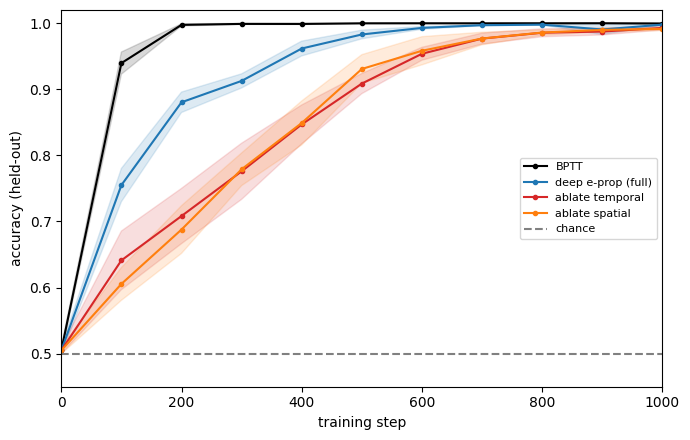

In [17]:
# ── Fig 2.1  Learning curves — equal final accuracy, credit quality sets speed ────
lc = load("exp2_learning_curves")
E2_EVAL = lc["eval_every"]
E2_LR = lc["lr"]
e2_curves = {m: (np.array(v[0]), np.array(v[1])) for m, v in lc["curves"].items()}

fig, ax = plt.subplots(figsize=(7, 4.5))
for meth, lab in e2_methods:
    mu, er = e2_curves[meth]
    x = np.arange(len(mu)) * E2_EVAL
    ax.plot(x, mu, "-o", ms=3, color=col[meth], label=lab)
    ax.fill_between(x, mu - er, mu + er, color=col[meth], alpha=0.15)
ax.axhline(0.5, color="gray", ls="--", label="chance")
ax.set_xlabel("training step"); ax.set_ylabel("accuracy (held-out)"); ax.set_ylim(0.45, 1.02)
# ax.set_title(f"Adam (lr={E2_LR:.0e}): equal final accuracy, credit quality sets speed")
ax.legend(fontsize=8)
ax.set_xlim([0,1000])
fig.tight_layout(); save_fig(fig, "exp2.1_learning_curves"); plt.show()


### 2.2 Gradient credit vs BPTT

Saved results/main_results/exp2.2_gradient_credit.pdf / .svg / .png


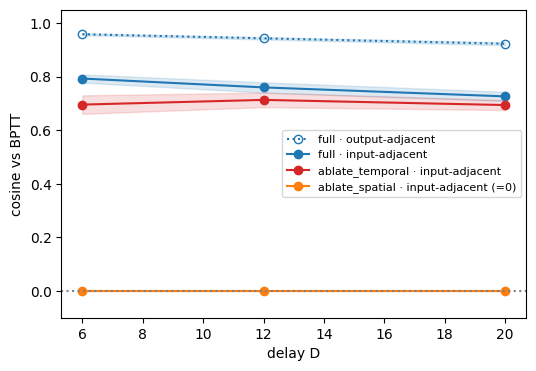

In [46]:
# ── Fig 2.2  Per-layer cosine vs BPTT across delays (+ cross-temporal credit share) ──
gc = load("exp2_gradient_credit")
DELAYS = gc["delays"]
e2_mean, e2_sem = gc["mean"], gc["sem"]   # keyed by str(delay) -> {full_low, ...}

def _ser(stat, k):
    return np.nan_to_num(np.array([stat[str(d)][k] for d in DELAYS], dtype=float))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for k, c, ls, lab, mfc in [("full_up", "C0", ":", "full · output-adjacent", "none"),
                           ("full_low", "C0", "-", "full · input-adjacent", "C0"),
                           ("temp_low", "C3", "-", "ablate_temporal · input-adjacent", "C3"),
                           ("spat_low", "C1", "-", "ablate_spatial · input-adjacent (=0)", "C1")]:
    mu, er = _ser(e2_mean, k), _ser(e2_sem, k)
    ax.plot(DELAYS, mu, marker="o", color=c, ls=ls, label=lab, markerfacecolor=mfc)
    ax.fill_between(DELAYS, mu - er, mu + er, color=c, alpha=0.15)
ax.axhline(0, color="gray", ls=":"); ax.set_xlabel("delay D"); ax.set_ylabel("cosine vs BPTT")
ax.set_ylim(-0.1, 1.05); ax.legend(fontsize=8)
save_fig(fig, "exp2.2_gradient_credit");
plt.show()

### 2.3 Convergence-speed significance

Steps to reach acc>=0.90 (paired sign-flip perm, Holm):
  full vs ablate_temporal    d_steps=   -217  dz=-1.71  p=0.0078  Holm=0.0234  *
  full vs ablate_spatial     d_steps=   -203  dz=-1.37  p=0.0234  Holm=0.0469  *
  temporal vs spatial        d_steps=    +14  dz=+0.18  p=0.6328  Holm=0.6328  ns
Saved results/main_results/exp2.3_speed_threshold.pdf / .svg / .png


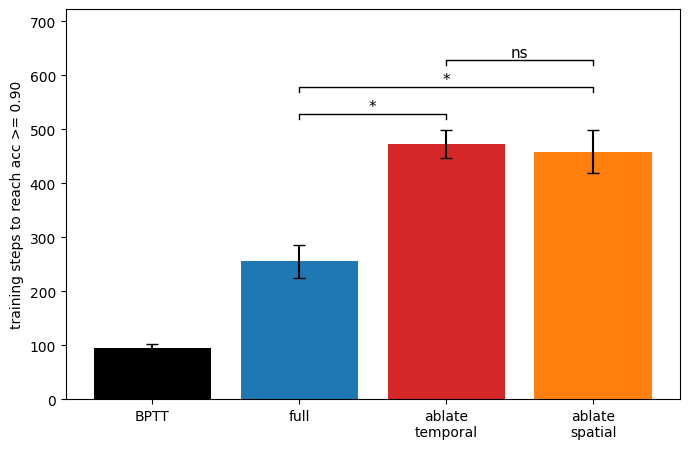


Cluster-permutation significant intervals (0-2200 steps):
  full vs ablate_temporal    [200-700] (p=0.008)
  full vs ablate_spatial     [100-400] (p=0.008), [1300-1600] (p=0.047)
  temporal vs spatial        none
Saved results/main_results/exp2.3b_speed_intervals.pdf / .svg / .png


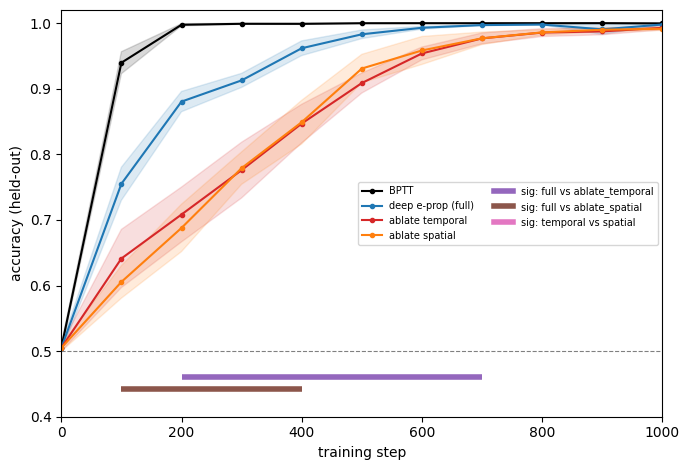

In [47]:
# ── Fig 2.3  Speed: steps-to-threshold bars + cluster-permutation intervals ───────
from experiments.stats import paired_report, holm, cluster_perm_test

lc = load("exp2_learning_curves")
E2_EVAL = lc["eval_every"]
e2_rows = {m: lc["per_seed"][m] for m, _ in e2_methods}   # ragged per-seed eval curves

E2_SPEED_COMPS = [("full", "ablate_temporal", "full vs ablate_temporal", "C4"),
                  ("full", "ablate_spatial",  "full vs ablate_spatial",  "C5"),
                  ("ablate_temporal", "ablate_spatial", "temporal vs spatial", "C6")]

def _stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

# ── (A) Steps-to-threshold ────────────────────────────────────────────────────
def steps_to_threshold(r, theta, eval_every=E2_EVAL):
    r = np.asarray(r, float)
    above = np.where(r >= theta)[0]
    if len(above) == 0:
        return float("nan")
    i = int(above[0])
    if i == 0:
        return 0.0
    y0, y1 = r[i - 1], r[i]
    frac = 0.0 if y1 == y0 else (theta - y0) / (y1 - y0)
    return (i - 1 + min(max(frac, 0.0), 1.0)) * eval_every

s2t = {m: np.array([steps_to_threshold(r, E2_THETA) for r in e2_rows[m]]) for m, _ in e2_methods}
reports = [(lab, a, b, paired_report(s2t[a], s2t[b])) for a, b, lab, _ in E2_SPEED_COMPS]
e2_spd_padj = holm([r["p_perm"] for *_, r in reports])
print(f"Steps to reach acc>={E2_THETA:.2f} (paired sign-flip perm, Holm):")
for (lab, a, b, r), pa in zip(reports, e2_spd_padj):
    print(f"  {lab:26s} d_steps={r['mean_diff']:+7.0f}  dz={r['cohen_dz']:+5.2f}  "
          f"p={r['p_perm']:.4f}  Holm={pa:.4f}  {_stars(pa)}")

order = ["bptt", "full", "ablate_temporal", "ablate_spatial"]
short = {"bptt": "BPTT", "full": "full", "ablate_temporal": "ablate\ntemporal",
         "ablate_spatial": "ablate\nspatial"}
means = {m: float(np.nanmean(s2t[m])) for m in order}
sems  = {m: float(np.nanstd(s2t[m], ddof=1) / np.sqrt(np.sum(~np.isnan(s2t[m])))) for m in order}
figA, axA = plt.subplots(figsize=(7, 4.6)); xs = np.arange(len(order))
bar_cols = [col[m] for m in order]
axA.bar(xs, [means[m] for m in order], color=bar_cols)
# Lighter grey error bars on the black BPTT bar so its SEM shows against the bar;
# the coloured bars keep black error bars.
for x, m, bc in zip(xs, order, bar_cols):
    ecol = "0.7" if bc in ("k", "black") else "black"
    axA.errorbar(x, means[m], yerr=sems[m], capsize=4, ecolor=ecol, elinewidth=1.5, ls="none")
axA.set_xticks(xs); axA.set_xticklabels([short[m] for m in order])
axA.set_ylabel(f"training steps to reach acc >= {E2_THETA:.2f}")
# axA.set_title(f"Convergence speed (Adam): steps to {E2_THETA:.0%} accuracy")
y0 = max(means[m] + sems[m] for m in order)
for k, (a, b, lab, _) in enumerate(E2_SPEED_COMPS):
    xa, xb = order.index(a), order.index(b); y = y0 * (1.06 + 0.10 * k)
    axA.plot([xa, xa, xb, xb], [y - y0 * 0.02, y, y, y - y0 * 0.02], color="k", lw=1)
    axA.text((xa + xb) / 2, y, _stars(e2_spd_padj[k]), ha="center", va="bottom", fontsize=11)
axA.set_ylim(0, y0 * 1.45)
figA.tight_layout(); save_fig(figA, "exp2.3_speed_threshold"); plt.show()

# ── (B) Cluster-permutation significant intervals over training ───────────────
n_common = min(len(r) for m, _ in e2_methods for r in e2_rows[m])
A = {m: np.array([r[:n_common] for r in e2_rows[m]]) for m, _ in e2_methods}
t_axis = np.arange(n_common) * E2_EVAL

e2_sig_intervals = {}
print(f"\nCluster-permutation significant intervals (0-{t_axis[-1]} steps):")
for a, b, lab, _c in E2_SPEED_COMPS:
    cl = cluster_perm_test(A[a] - A[b])
    sig = [c for c in cl if c["p_cluster"] < 0.05]
    e2_sig_intervals[(a, b)] = sig
    spans = ", ".join(f"[{t_axis[c['t0']]}-{t_axis[c['t1']]}] (p={c['p_cluster']:.3f})"
                      for c in sig) or "none"
    print(f"  {lab:26s} {spans}")

figB, axB = plt.subplots(figsize=(7, 4.8))
for meth, lab in e2_methods:
    mu = A[meth].mean(0)
    er = A[meth].std(0, ddof=1) / np.sqrt(A[meth].shape[0])
    axB.plot(t_axis, mu, "-o", ms=3, color=col[meth], label=lab)
    axB.fill_between(t_axis, mu - er, mu + er, color=col[meth], alpha=0.15)
axB.axhline(0.5, color="gray", ls="--", lw=0.8)
axB.set_xlabel("training step"); axB.set_ylabel("accuracy (held-out)")
axB.set_ylim(0.40, 1.02)
axB.set_xlim(0,1000)
# axB.set_title("Where convergence-speed gaps are significant (cluster permutation)")
ybar = 0.46
for k, (a, b, lab, cc) in enumerate(E2_SPEED_COMPS):
    y = ybar - 0.018 * k
    for c in e2_sig_intervals[(a, b)]:
        axB.plot([t_axis[c["t0"]], t_axis[c["t1"]]], [y, y], color=cc, lw=4, solid_capstyle="butt")
    axB.plot([], [], color=cc, lw=4, label=f"sig: {lab}")
axB.legend(fontsize=7, ncol=2, loc="right")
figB.tight_layout(); save_fig(figB, "exp2.3b_speed_intervals"); plt.show()


### 2.4 Credit summary

Saved results/main_results/exp2.4_credit_summary.pdf / .svg / .png


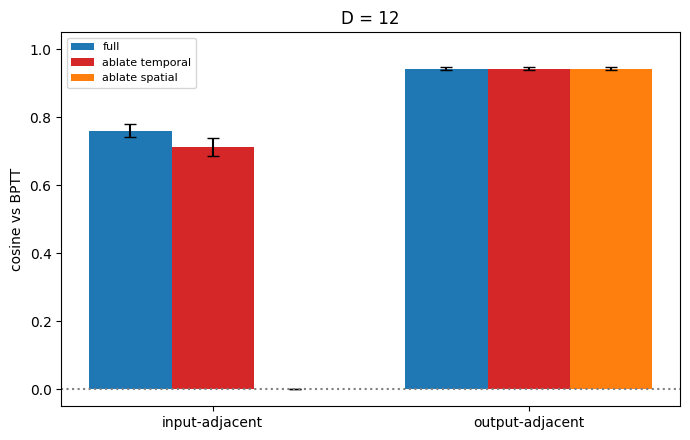

In [48]:
# ── Fig 2.4  Credit summary: lower- vs top-layer cosine at the main delay ─────
gc = load("exp2_gradient_credit")
DELAYS = gc["delays"]
e2_mean, e2_sem = gc["mean"], gc["sem"]

db = E2_DELAY_MAIN if str(E2_DELAY_MAIN) in e2_mean else DELAYS[len(DELAYS) // 2]
kf = {("full", "low"): "full_low", ("full", "top"): "full_up",
      ("ablate_temporal", "low"): "temp_low", ("ablate_temporal", "top"): "temp_up",
      ("ablate_spatial", "low"): "spat_low", ("ablate_spatial", "top"): "spat_up"}
fig, ax = plt.subplots(figsize=(7, 4.5)); x = np.arange(2); w = 0.26
for i, (meth, c) in enumerate([("full", "C0"), ("ablate_temporal", "C3"), ("ablate_spatial", "C1")]):
    mus = [np.nan_to_num(e2_mean[str(db)][kf[(meth, l)]]) for l in ("low", "top")]
    ers = [np.nan_to_num(e2_sem[str(db)][kf[(meth, l)]]) for l in ("low", "top")]
    ax.bar(x + (i - 1) * w, mus, w, yerr=ers, capsize=4, color=c, label=meth.replace("ablate_", "ablate "))
ax.set_xticks(x); ax.set_xticklabels(["input-adjacent", "output-adjacent"]); ax.set_ylim(-0.05, 1.05)
ax.axhline(0, color="gray", ls=":"); ax.set_ylabel("cosine vs BPTT")
ax.set_title(f"D = {db}")
ax.legend(fontsize=8); fig.tight_layout(); save_fig(fig, "exp2.4_credit_summary"); plt.show()

### 2.5 Cue decoding

Saved results/main_results/exp2.5_cue_decoding.pdf / .svg / .png


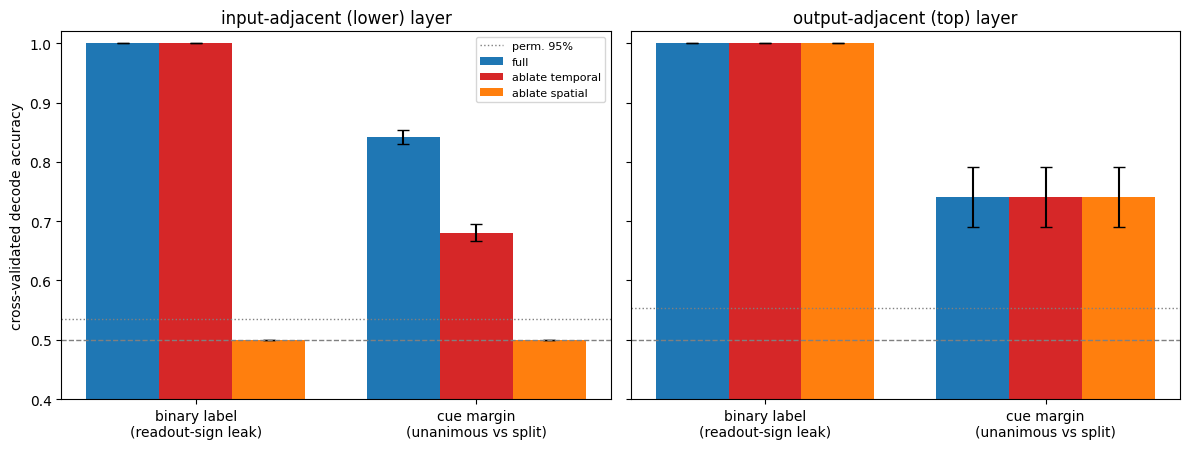

In [49]:
# ── Fig 2.5  Cue decoding: grouped decode-accuracy bars, from the saved summary.
cd = load("exp2_cue_decoding")
summary = cd["summary"]
E2B_MODES = ["full", "ablate_temporal", "ablate_spatial"]
E2B_COLOR = {"full": "C0", "ablate_temporal": "C3", "ablate_spatial": "C1"}
_TG = [("label", "binary label\n(readout-sign leak)"), ("margin", "cue margin\n(unanimous vs split)")]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, lyr, ttl in [(axes[0], "lower", "input-adjacent (lower) layer"),
                     (axes[1], "upper", "output-adjacent (top) layer")]:
    x = np.arange(len(_TG)); w = 0.26
    for i, mode in enumerate(E2B_MODES):
        mus = [summary[lyr][mode][t]["acc"] for t, _ in _TG]
        ers = [summary[lyr][mode][t]["sem"] for t, _ in _TG]
        ax.bar(x + (i - 1) * w, mus, w, yerr=ers, capsize=4, color=E2B_COLOR[mode],
               label=mode.replace("ablate_", "ablate "))
    chi = np.mean([summary[lyr][mode][t]["chance_hi"] for mode in E2B_MODES for t, _ in _TG])
    ax.axhline(0.5, color="gray", ls="--", lw=1)
    ax.axhline(chi, color="gray", ls=":", lw=1, label="perm. 95%")
    ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in _TG])
    ax.set_title(ttl); ax.set_ylim(0.4, 1.02)
    if lyr == "lower":
        ax.set_ylabel("cross-validated decode accuracy"); ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); save_fig(fig, "exp2.5_cue_decoding"); plt.show()

### 2.5 Cue-credit ladder (distilled)

A single-panel "ladder" summary of the cue-decoding result above: the input-adjacent (lower) layer's **cue-margin** decode accuracy across the three ablation modes. Each rung restores one term of the cross-layer eligibility trace (`eps^z = spatial depth seed + temporal carry`), so the climb from chance shows how each term contributes cue-specific credit. Reconstructed from the saved `exp2_cue_decoding` summary — no retraining.

Saved results/main_results/exp2.5_cue_decoding_ladder.pdf / .svg / .png


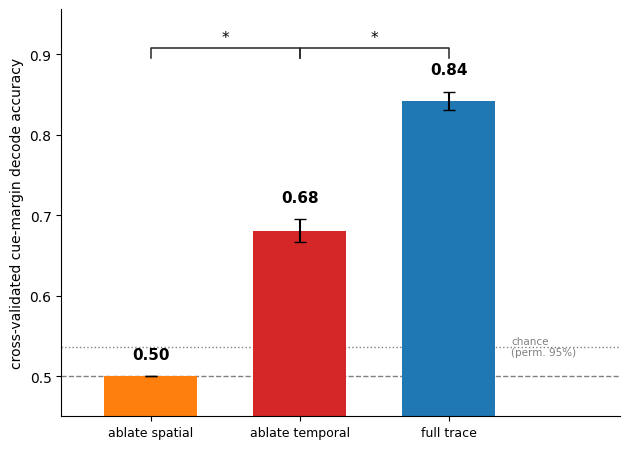

In [52]:
# Distilled single-panel view of the cue-decoding result: the lower-layer cue-margin
# decode accuracy climbs as each of the two cross-layer trace terms is restored.
# Pure re-plot of results/exp2_cue_decoding.json (saved by the cue-decoding cell).
cd = load("exp2_cue_decoding")
_S = cd["summary"]["lower"]                      # input-adjacent (lower) layer only
_LADDER = ["ablate_spatial", "ablate_temporal", "full"]   # low -> high (the "ladder")
_LAB = ["ablate spatial",
        "ablate temporal",
        "full trace"]
_COL = {"full": "C0", "ablate_temporal": "C3", "ablate_spatial": "C1"}

acc = np.array([_S[m]["margin"]["acc"] for m in _LADDER])
sem = np.array([_S[m]["margin"]["sem"] for m in _LADDER])
chance_hi = float(np.mean([_S[m]["margin"]["chance_hi"] for m in _LADDER]))
x = np.arange(len(_LADDER))

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.bar(x, acc, 0.62, yerr=sem, capsize=4,
       color=[_COL[m] for m in _LADDER], edgecolor="none", zorder=2)

# value labels above each bar
for xi, a, se in zip(x, acc, sem):
    ax.text(xi, a + se + 0.018, f"{a:.2f}", ha="center", va="bottom",
            fontweight="bold", fontsize=11, zorder=5)

# chance references
ax.axhline(0.5, color="gray", ls="--", lw=1, zorder=1)
ax.axhline(chance_hi, color="gray", ls=":", lw=1, zorder=1)
ax.text(x[-1] + 0.42, chance_hi, "chance\n(perm. 95%)", va="center", ha="left",
        fontsize=7.5, color="gray")

# annotate the two increments = the two trace terms
def _rise(i, text, color):
    xm = (x[i] + x[i + 1]) / 2.0
    ymid = (acc[i] + acc[i + 1]) / 2.0
    ax.annotate("", xy=(x[i + 1] - 0.12, acc[i + 1] - 0.01),
                xytext=(x[i] + 0.12, acc[i] + 0.01),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.4), zorder=3)
    ax.text(xm + 0.16, ymid, text, ha="left", va="center", fontsize=8.5,
            color=color, style="italic")
# _rise(0, "a thin-layer\ntrace term", "0.30")
# _rise(1, "cross-layer\nshare", "0.30")

# significance brackets over each increment (non-overlapping error bars => significant)
_ytop = acc.max() + max(sem) + 0.05
for i in range(len(x) - 1):
    signif = (acc[i + 1] - sem[i + 1]) > (acc[i] + sem[i])
    yb = _ytop + 0.001
    ax.plot([x[i], x[i], x[i + 1], x[i + 1]],
            [yb - 0.012, yb, yb, yb - 0.012], color="0.15", lw=1.1, zorder=4)
    ax.text((x[i] + x[i + 1]) / 2.0, yb + 0.004, "*" if signif else "n.s.",
            ha="center", va="bottom", fontsize=11, zorder=4)

# note: the binary label is trivially decodable (readout-sign leak), so it is NOT the test
# ax.text(0.02, 0.60, "binary label ≈ 1.0 everywhere\n(readout-sign leak, not cue credit)",
#         transform=ax.transAxes, ha="left", va="top", fontsize=7.5, color="0.35",
#         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", lw=0.6))

ax.set_xticks(x); ax.set_xticklabels(_LAB, fontsize=9)
ax.set_ylabel("cross-validated cue-margin decode accuracy")
ax.set_ylim(0.45, _ytop + 0.05)
ax.set_xlim(-0.6, len(x) - 0.4 + 0.55)
# ax.set_title("Lower-layer cue credit: a ladder across the two trace terms", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_fig(fig, "exp2.5_cue_decoding_ladder")
plt.show()

### 2.6 Reservoir control

Saved results/main_results/exp2.6_reservoir_control.pdf / .svg / .png


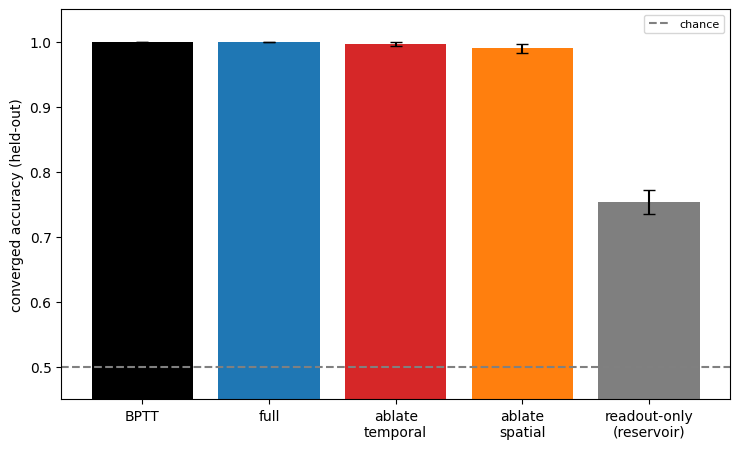

Saved results/main_results/exp2.6b_reservoir_curves.pdf / .svg / .png


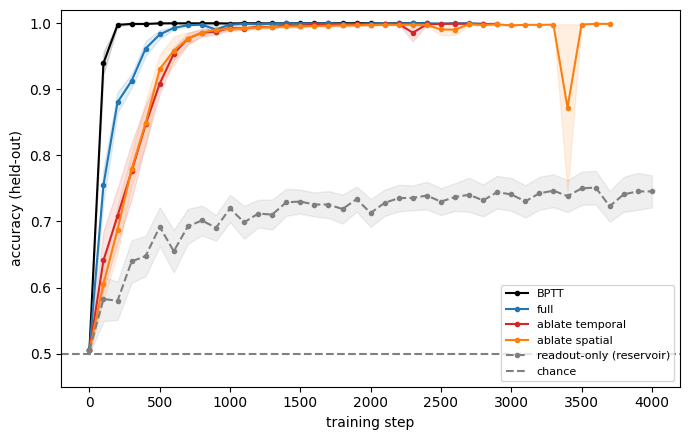

Each trainable rule vs the reservoir floor (paired, Holm-corrected):
  full − reservoir               meanD=+0.246 dz=+4.87 p=0.0078 Holm=0.0234 *
  ablate_temporal − reservoir    meanD=+0.243 dz=+4.43 p=0.0078 Holm=0.0234 *
  ablate_spatial − reservoir     meanD=+0.236 dz=+4.37 p=0.0078 Holm=0.0234 *


In [53]:
# ── Fig 2.6  Reservoir control: converged-accuracy bars + overlay + significance.
rc = load("exp2_reservoir_control")
lc = load("exp2_learning_curves")
E2_EVAL = lc["eval_every"]
e2_curves = {m: (np.array(v[0]), np.array(v[1])) for m, v in lc["curves"].items()}
col.setdefault("readout", "C7")

bar_methods = [("bptt", "BPTT"), ("full", "full"), ("ablate_temporal", "ablate\ntemporal"),
               ("ablate_spatial", "ablate\nspatial"), ("readout", "readout-only\n(reservoir)")]
means, sems = rc["means"], rc["sems"]
figc, axc = plt.subplots(figsize=(7.5, 4.6)); xs = np.arange(len(bar_methods))
axc.bar(xs, [means[m] for m, _ in bar_methods], yerr=[sems[m] for m, _ in bar_methods],
        capsize=4, color=[col[m] for m, _ in bar_methods])
axc.set_xticks(xs); axc.set_xticklabels([lab for _, lab in bar_methods])
axc.set_ylabel("converged accuracy (held-out)"); axc.axhline(0.5, color="gray", ls="--", label="chance")
axc.set_ylim(0.45, 1.05); axc.legend(fontsize=8)
figc.tight_layout(); save_fig(figc, "exp2.6_reservoir_control"); plt.show()

res_mu, res_sem = np.array(rc["res_curve"][0]), np.array(rc["res_curve"][1])
figd, axd = plt.subplots(figsize=(7, 4.5))
for meth, lab in [("bptt", "BPTT"), ("full", "full"),
                  ("ablate_temporal", "ablate temporal"), ("ablate_spatial", "ablate spatial")]:
    mu, er = e2_curves[meth]; x = np.arange(len(mu)) * E2_EVAL
    axd.plot(x, mu, "-o", ms=3, color=col[meth], label=lab)
    axd.fill_between(x, mu - er, mu + er, color=col[meth], alpha=0.12)
xr = np.arange(len(res_mu)) * E2_EVAL
axd.plot(xr, res_mu, "--o", ms=3, color=col["readout"], label="readout-only (reservoir)")
axd.fill_between(xr, res_mu - res_sem, res_mu + res_sem, color=col["readout"], alpha=0.12)
axd.axhline(0.5, color="gray", ls="--", label="chance")
axd.set_xlabel("training step"); axd.set_ylabel("accuracy (held-out)"); axd.set_ylim(0.45, 1.02)
axd.legend(fontsize=8); figd.tight_layout(); save_fig(figd, "exp2.6b_reservoir_curves"); plt.show()

print("Each trainable rule vs the reservoir floor (paired, Holm-corrected):")
for r in rc["comparisons"]:
    p = r["p_holm"]; sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {r['comparison']:30s} meanD={r['mean_diff']:+.3f} dz={r['cohen_dz']:+.2f} "
          f"p={r['p_perm']:.4f} Holm={p:.4f} {sig}")

---
## Save generated figures & results to git

Generalised version of the old replot-and-commit cell. Instead of a hard-coded figure
list, it stages **every** artefact this notebook writes — all figures under
`results/main_results/` (`.png` / `.svg` / `.pdf`) plus the metrics JSON in `results/`.
Any new experiment's figures are therefore picked up automatically, no edits needed.

By default it stages and makes a **local commit** but does **not push** — flip the
flags at the top of the cell to stage-only, or to also push.

In [ ]:
# ── Save every figure/result this run produced, then commit & (optionally) push ──
# Generalised replacement for the old per-figure commit cell: it stages EVERYTHING
# the notebook writes, so new experiments are picked up with no edits here.
import glob, subprocess

TARGET_BRANCH = ""    # "" = current branch. Else e.g. "main" or "Y/repo_cleaning":
                      # the branch is checked out (created from origin if needed)
                      # BEFORE committing, so the commit AND push land there.
COMMIT_MSG = "Update figures & results from notebook run"
DO_COMMIT  = True     # False -> only `git add` (stage), leaving the commit to you
DO_PUSH    = False    # True  -> push after committing (also pushes earlier unpushed commits)
GIT_NAME   = ""       # optional commit-author overrides (needed on a fresh Colab)
GIT_EMAIL  = ""

def _run(*cmd):
    print("$", " ".join(cmd))
    r = subprocess.run(cmd, capture_output=True, text=True)
    out = (r.stdout + r.stderr).strip()
    if out:
        print(out)
    return r

def _out(*cmd):
    return subprocess.run(cmd, capture_output=True, text=True).stdout.strip()

def _exists(ref):
    return subprocess.run(["git","rev-parse","--verify",ref],
                          capture_output=True).returncode == 0

proceed = True

# 0) Switch to the requested branch first, so everything below lands there.
if TARGET_BRANCH and _out("git","rev-parse","--abbrev-ref","HEAD") != TARGET_BRANCH:
    _run("git", "fetch", "origin", TARGET_BRANCH)   # harmless if it doesn't exist yet
    sw = _run("git", "switch", TARGET_BRANCH)        # existing local branch?
    if sw.returncode != 0:                           # no -> create it
        if _exists(f"origin/{TARGET_BRANCH}"):
            sw = _run("git","switch","-c",TARGET_BRANCH,"--track",f"origin/{TARGET_BRANCH}")
        else:
            sw = _run("git","switch","-c",TARGET_BRANCH)   # brand-new branch off HEAD
    if sw.returncode != 0:
        proceed = False
        print(f"\n[!] Could not switch to '{TARGET_BRANCH}' — usually because the "
              "regenerated files differ from that branch's versions.\n"
              "    Fix: run the whole notebook on that branch from the start, or set\n"
              "    TARGET_BRANCH to the branch you generated on and merge later.")

if proceed:
    fig_paths  = sorted(glob.glob(f"{FIGS}/*.png")
                        + glob.glob(f"{FIGS}/*.svg")
                        + glob.glob(f"{FIGS}/*.pdf"))
    json_paths = sorted(glob.glob(f"{RESULTS}/*.json"))
    paths = fig_paths + json_paths

    if not paths:
        print("No figures/results found to stage — run the cells above first.")
    else:
        print(f"Staging {len(fig_paths)} figures + {len(json_paths)} JSON file(s).")
        _run("git", "add", *paths)

        # 1) Commit — only if the staged tree differs from the last commit.
        if subprocess.run(["git","diff","--cached","--quiet"]).returncode != 0:
            if DO_COMMIT:
                if GIT_NAME:  _run("git","config","user.name",GIT_NAME)
                if GIT_EMAIL: _run("git","config","user.email",GIT_EMAIL)
                if not (_out("git","config","user.name") and _out("git","config","user.email")):
                    print("No git identity set — using a repo-local fallback "
                          "(set GIT_NAME / GIT_EMAIL above to use your own).")
                    _run("git","config","user.name","notebook")
                    _run("git","config","user.email","notebook@localhost")
                if _run("git","commit","-m",COMMIT_MSG).returncode != 0:
                    print("[!] Commit FAILED (see above) — nothing was committed.")
            else:
                print("Staged only (DO_COMMIT=False).")
        else:
            print("Nothing new to commit — staged files already match the last commit.")

        # 2) Push — INDEPENDENT of step 1, so an earlier unpushed commit still goes out.
        if DO_PUSH:
            branch = _out("git","rev-parse","--abbrev-ref","HEAD")
            has_up = subprocess.run(["git","rev-parse","--abbrev-ref","@{u}"],
                                    capture_output=True).returncode == 0
            ahead = _out("git","rev-list","--count","@{u}..HEAD") if has_up else "?"
            if has_up and ahead == "0":
                print(f"\nNothing to push — '{branch}' already matches its remote.")
            else:
                print(f"\nPushing '{branch}'…")
                cmd = ["git","push"] if has_up else ["git","push","-u","origin",branch]
                if _run(*cmd).returncode != 0:
                    print("[!] Push FAILED — on Colab this needs GitHub credentials/token.")

# 3) Status readout.
print("\n── git status ──")
print("branch:", _out("git","rev-parse","--abbrev-ref","HEAD"))
print(_out("git","status","-sb"))
print("recent commits:"); print(_out("git","log","--oneline","-3"))
print("exp1.1 figure committed in HEAD:",
      subprocess.run(["git","cat-file","-e","HEAD:results/main_results/exp1.1_learning_curves.png"],
                     capture_output=True).returncode == 0)